<a href="https://colab.research.google.com/github/Sam-Arkle/CS5455/blob/main/svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# svm project for topics in machine learning class

import numpy as np
# from matplotlib import pyplot as plt

"""Write a Python function that computes the “net input” from the data matrix (numpy array) and
weight vector (numpy array). You can assume that the dimensions are correct: X is an n×m matrix,
w is a length m vector, and w0 is a scalar.

z(i) = w0 + x_1^(i) w_1 + x_2^(i) w_2 + · · · + x_m^(i) w_m
z = w0 + Xw
"""
def net_input_numpy(x, w, w0):
  """
  Return the vector of net inputs given the data matrix, weight vector,
  and bias.
  :param x: data matrix (n x m)
  :param w: weight vector (length m)
  :param w0: bias/intercept/negative threshold
  :return: vector of net inputs (length n)
  """
  z = np.zeros(x.shape[0])
  for i in range(x.shape[0]):
    z_val = 0
    for j in range(x.shape[1]):
      z_val +=  x[i][j] * w[j]
    z[i] = w0 + z_val
  return z

In [ ]:
# Testing the function
np.random.seed(1)
n, m = 3, 2
x = np.random.randint(-9, 10, (n, m))
w = np.random.randint(-9,10,m) / 10
b = np.random.randint(-9, 10) /10

net_input_numpy(x, w, b)

# second test
w = np.random.randint(-9, 10, m) / 10

b = np.random.randint(-9,10) / 10



In [ ]:
"""
Write a function that computes the partial derivative of the Lagrangian function for SVM with
respect to the bias w0. You may use the numpy library.
The primal Lagrangian for SVM can be written in terms of scalars: (see the handout)
"""

def svm_w0_gradient(x, y, w, w0, lambda_):
  """
  Return the partial derivative of the primal Lagrangian function for SVM
  with respect to the bias 'w0'
  :param x: data matrix (n x m)
  :param y: target vector {-1, 1} (length n)
  :param w: weight vector (length m)
  :param w0: bias/intercept/negative threshold
  :param lambda_: lambda vector (length n)
  :return: The partial derivative dL/dw_0
  """
  # See notebook for calculation of the derivative. Should equal: - Sum lambda ^(i) * y ^ (i)
  sum = 0
  for i in range(len(y)):
    sum += y[i] * lambda_[i]
  return 0-sum


In [ ]:
# Testing the function
np.random.seed(1)
n, m = 4, 3
x = np.random.randint(-9, 10, (n,m))
w = np.random.randint(-9, 10, m) / 10
b = np.random.randint(-9,10) / 10
y = (net_input_numpy(x,w,b) >= 0).astype(int) * 2 - 1
lambda_ = np.random.randint(0,10,n) / 10
svm_w0_gradient(x, y, w, b, lambda_)

# second test
n,m = 10,5
x = np.random.randint(-9,10,(n,m))
w = np.random.randint(-9,10,m) / 10
b = np.random.randint(-9,10)/10
y = (net_input_numpy(x, w, b) >= 0).astype(int) * 2 - 1
lambda_ = np.random.randint(0,10,n) / 10
svm_w0_gradient(x,y,w,b,lambda_)


-0.5

In [ ]:
"""
Write a Python function that computes the gradient of the Lagrangian function for SVM with
respect to the weight vector w. You may use the numpy library.
The primal Lagrangian for SVM can be written in terms of scalars (see homework sheet for formulas. See notebook for calculation of gradient)
"""

def svm_w_gradient(x, y, w, w0, lambda_):
  """
  Return the gradient vector of the primal Lagrangian function for the SVM
  with respect to the weight vector 'w'
  :param x: data matrix (n x m)
  :param y: target vector {-1, 1} (length n)
  :param w: weight vector (length m)
  :param w0: bias/intercept/negative threshold
  :param lambda_: lambda vector (length n)
  :return: The gradient vector of the Lagrangian function w.r.t. the weights:
  (dL/dw_1, dL/dw_2, ..., dL/dw_m)
  """
  diff_w = np.zeros(x.shape[1])
  for j in range(x.shape[1]):
    sum = 0
    for i in range(x.shape[0]):
      sum +=  lambda_[i] * y[i] * x[i][j]
    diff_w[j] = w[j] - sum

  return diff_w


In [ ]:
# Testing the above function
np.random.seed(1)
n,m = 4,3
x = np.random.randint(-9, 10, (n,m))
w = np.random.randint(-9, 10, m) / 10
b = np.random.randint(-9,10) / 10
y = (net_input_numpy(x,w,b) >= 0).astype(int) * 2 - 1
lambda_ = np.random.randint(0,10,n) / 10
svm_w_gradient(x,y,w,b,lambda_)

# second test
n,m = 10,5
x = np.random.randint(-9,10,(n,m))
w = np.random.randint(-9,10,m) / 10
b = np.random.randint(-9,10)/10
y = (net_input_numpy(x, w, b) >= 0).astype(int) * 2 - 1
lambda_ = np.random.randint(0,10,n) / 10
svm_w_gradient(x,y,w,b,lambda_)

array([  6.2, -14.2,  16.2,   6.6, -13.1])

In [ ]:
"""
Write a function that computes the gradient of the Lagrangian function for SVM with respect to
the Lagrange multipliers vector λ. You may use the numpy library.
The primal Lagrangian for SVM can be written in terms of scalars:"""

def svm_lambda_gradient(x, y, w, w0, lambda_):
  """
  Return the gradient vector of the primal Lagrangian function for the SVM
  with respect to the lambda vector 'lambda_'
  :param x: data matrix (n x m)
  :param y: target vector {-1, 1} (length n)
  :param w: weight vector (length m)
  :param w0: bias/intercept/negative threshold
  :param lambda_: lambda vector (length n)
  :return: The gradient vector of the Lagrangian function w.r.t. the weights:
  (dL/d lambda_1, dL/d lambda_2, ..., dL/d lambda_n)
  """
  # From the book calculations we see the gradient we need is just - u
  z = net_input_numpy(x, w, w0)

  u = y * z - 1
  grad = -u

  return grad

In [ ]:
# Testing the above function
np.random.seed(1)
n,m = 4,3
x = np.random.randint(-9, 10, (n,m))
w = np.random.randint(-9, 10, m) / 10
b = np.random.randint(-9,10) / 10
y = (net_input_numpy(x,w,b) >= 0).astype(int) * 2 - 1
lambda_ = np.random.randint(0,10,n) / 10
svm_lambda_gradient(x,y,w,b,lambda_)

# Second test
n,m = 10,5
x = np.random.randint(-9,10,(n,m))
w = np.random.randint(-9,10,m) / 10
b = np.random.randint(-9,10)/10
y = (net_input_numpy(x, w, b) >= 0).astype(int) * 2 - 1
lambda_ = np.random.randint(0,10,n) / 10
svm_lambda_gradient(x,y,w,b,lambda_)

array([-0.7, -5.1, -1.6,  0.3, -6.3, -3.3, -3.2,  0.6, -5.6, -0.7])

In [ ]:
"""
To get an idea of whether or not the SVM algorithm is converging, we can look at the partial
derivatives of the Lagrangian multipliers. We might expect the gradient to approach zero for all λ(i)
but that’s not the case. Convergence means that the parameters can’t be improved. To satisfy the
constraint that 0 ≤ λ(i) ≤ C, the lagrangian multipliers might get clamped at zero or C. If λ = 0
and ∂LP
∂λ < 0, it can’t be improved by following the slope. Similarly, if λ = C and ∂LP
∂λ > 0, it
can’t be improved by following the slope. To measure convergence, we want to consider the “active”
gradient, meaning the gradient that can actually change the parameters.
Write a function that takes the λ vector, gradient vector ∂LP
∂λ , and C hyperparameter and returns
the “active” gradient of λ so that the i-th element is at least −λ(i) and at most C − λ(i).
"""

def svm_active_lambda_gradient(lambda_, lambda_gradient, c=np.inf):
  """
  Return the "active" part of the gradient of the primal Lagrangian
  function for SVM with respect to the Lagrangian multipliers. Each
  d(L)/d(lambda) should be at least -lambda and at most C-lambda.
  :param lambda_: lambda vector (length n)
  :param lambda_gradient: gradient vector of L_P w.r.t. lambda (length n)
  :param c: SVM C-parameter
  :return: The "active" gradient vector of the Lagrangian function
  with respect to the lambdas
  """
  active = np.zeros(len(lambda_))
  for i in range(len(lambda_)):
    lower_bound = -lambda_[i]
    upper_bound = c - lambda_[i]
    if lower_bound <= lambda_gradient[i]:
      if lambda_gradient[i] <= upper_bound:
        active[i] = lambda_gradient[i]
      else: active[i] = upper_bound
    else: active[i] = lower_bound

  return active




In [95]:
# # testing the above function
# np.random.seed(1)
# n = 10
# c = 1
# lambda_ = np.random.randint(0,11,n)/10
# lambda_gradient = np.random.randint(-10,11,n)/10
# svm_active_lambda_gradient(lambda_, lambda_gradient, c)

# # Second test
# np.random.seed(2)
# c = 2
# lambda_ = np.random.randint(0,21,n)/10
# lambda_gradient = np.random.randint(-20,21,n)/10
# svm_active_lambda_gradient(lambda_, lambda_gradient, c)

# # new test for when c is 0
# c = 0
# lambda2 = svm_active_lambda_gradient(lambda_, lambda_gradient, c)
# svm_active_lambda_gradient(lambda2, lambda_gradient, c)

# # Third test
# lambda_ = [-2.58028246,  0.12934291, -0.35436216, -0.1820052,  -0.55733871,  1.34548035,
# 0.43166368, -1.42094879, -0.08790486, -3.05900166, -2.44275178, -2.05504406,
#  -0.18312105, -1.55384901,  0.20790177, -1.38072854,  0.28197509, -0.12587103,
#   1.34280674, -0.85829831]
# svm_active_lambda_gradient(lambda_, lambda_gradient, c)




IndexError: index 10 is out of bounds for axis 0 with size 10

In [ ]:
"""
Write a function that takes the λ vector and C hyperparameter and returns a boolean array index
indicating which samples are support vectors. For example, if there were n = 5 samples and the
first three were support vectors, it would return a numpy boolean index array:
array([True, True, True, False, False])
"""
def svm_support_vectors(lambda_, c):
  """
  Return a boolean array index indicating which samples are support vectors.
  :param lambda_: lambda vector (length n)
  :param c: SVM C-parameter
  :return: The boolean array indexing the support vectors
  """
  # for i in range(len(lambda_)):
  #   lambda_[i] = True if lambda_ != 0 else  False
  support_0 = lambda_ > 0
  support_1 = lambda_ <= c
  support = support_0 & support_1
  return support

In [ ]:
# Testing the above function
np.random.seed(1)
c = np.inf
lambda_ = np.array([0, 22.1, 0, 6.1, 0, 0, 0, 28.2])
svm_support_vectors(lambda_, c)

# Another test
c = 10
lambda_ =  np.array([0, 10, 0, 6.1, 0, 3.9, 0, 10])
svm_support_vectors(lambda_, c)

array([False,  True, False,  True, False,  True, False,  True])

In [ ]:
"""
Write a function that takes the λ vector and C hyperparameter and returns a boolean array index
indicating which samples are are on their correct hyperplane. For example, if there were n = 5
samples and the first three were support vectors, it would return a numpy boolean index array:
array([True, True, True, False, False])
"""
def svm_on_correct_hyperplane(lambda_, c):
  """
  Return a boolean index array indicating which samples are on their correct
  hyperplane.
  :param lambda_: lambda vector (length n)
  :param c: SVM C-parameter
  :return: The boolean array indexing the support vectors
  """
  correct_hyperplane = (lambda_ > 0) & (lambda_ < c)
  return correct_hyperplane



In [ ]:
# Testing the above function
np.random.seed(1)
c = np.inf
lambda_ = np.array([0, 22.1, 0, 6.1, 0, 0, 0, 28.2])
svm_on_correct_hyperplane(lambda_, c)

# Another test
c = 10
lambda_ =  np.array([0, 10, 0, 6.1, 0, 3.9, 0, 10])
svm_on_correct_hyperplane(lambda_, c)

array([False, False, False,  True, False,  True, False, False])

In [ ]:
"""
Write a function that takes the data matrix X, target vector y, weight vector w and bias w0, and
returns a vector of ξ, where ξ(i) = max(0, 1 − y(i)z(i)).
"""

def svm_ksi(x, y, w, w0):
  """
  Return the vector of slack variables, ksi.
  :param x: data matrix (n x m)
  :param y: target vector {-1, 1} (length n)
  :param w: weight vector (length m)
  :param w0: bias/intercept/negative threshold
  :return: The ksi-vector
  """
  z = net_input_numpy(x, w, w0)
  sigma = np.zeros(x.shape[0])
  for i in range(x.shape[0]):
    sigma[i] = max(0, 1 - (y[i] * z[i]))
  return sigma


In [ ]:
# Testing the above function
np.random.seed(1)
n,m = 4,3
x = np.random.randint(-9, 10, (n,m))
w = np.random.randint(-9, 10, m) / 10
b = np.random.randint(-9,10) / 10
y = (net_input_numpy(x,w,b) >= 0).astype(int) * 2 - 1
svm_ksi(x,y,w,b)

# Second test
n,m = 10,5
x = np.random.randint(-9,10,(n,m))
w = np.random.randint(-9,10,m) / 10
b = np.random.randint(-9,10)/10
y = (net_input_numpy(x, w, b) >= 0).astype(int) * 2 - 1
svm_ksi(x,y,w,b)


array([0. , 0.9, 0. , 0. , 0. , 0. , 0.3, 0. , 0. , 0. ])

In [ ]:
"""
Write a function that takes the ξ vector and returns a boolean array index indicating which samples
are are misclassified. For example, if there were n = 5 samples and the first three were support
vectors, it would return a numpy boolean index array:
array([True, True, True, False, False])
"""
def svm_misclassified(ksi):
  """
  Return a boolean array index indicating which samples are misclassified.
  :param ksi: ksi vector (length n)
  :return: The boolean array indexing the misclassified samples
  """
  misclassified = ksi > 1
  return misclassified



In [ ]:
np.random.seed(2)
ksi = np.random.randint(0, 100, 5) / 10
svm_misclassified(ksi)

array([ True,  True,  True,  True,  True])

In [121]:
"""
For this function we're going to put everything together. See the homework sheet for the algorithm it will follow
"""
def svm_optimization(x, y, c, eta, n_iter):
  """
  Uses the gradient of the primal Lagrangian function for Support Vector
  Machines to estimate the weights, bias, and Lagrangian multipliers.
  :param x: data matrix (n x m)
  :param y: target vector {-1, 1} (length n)
  :param c: SVM 'C' parameter
  :param eta: learning rate
  :param n_iter: number of epochs
  :return: The weight vector (length m), bias, and Lagrangian multiplier
  vector (length n)
  """
  n = x.shape[0]
  m = x.shape[1]
  #initialization phase
  w = np.zeros(m)     # weights
  w0 = 0              # the bias
  lambda_ = np.ones(n)

  print_numbers = [i * (10 ** j) for j in range(4) for i in range(1, 10)]

  #iterative phase
  for i in range(1,n_iter + 1):
    #determine gradients
    diff_w0 = svm_w0_gradient(x, y, w, w0, lambda_)
    diff_w = svm_w_gradient(x,y,w,w0,lambda_)
    diff_lambda = svm_lambda_gradient(x,y,w,w0,lambda_)
    diff_active_lambda = svm_active_lambda_gradient(lambda_, diff_lambda, c)

    #printing max values
    if i in print_numbers:
      # print(f"This is the value for diff_w0: {diff_w0}")
      # print(f"This is the differential with respect to w: {diff_w}")
      max_dwj = np.max(np.abs(diff_w))
      # print(f"This is the differential with respect to lambda: {diff_lambda}")
      # print(f"This is the differential with respect to active lambda: {diff_active_lambda}")
      # print(f"This is the lambda values: {lambda_}")

      max_dlambda = np.max(np.abs(diff_active_lambda))
      print(f"epoch\t{i}: max(|dL/dwj|) = {max_dwj:.3e}, max(|active(dL/d lambda)|) = {max_dlambda:.3e}")

    #updates
    w0 -= eta * diff_w0
    w -= eta * diff_w
    lambda_ += eta * diff_lambda
    lambda_ = np.clip(lambda_ , 0, c)
    # lambda_ = svm_active_lambda_gradient(lambda_, diff_lambda, c)

  ksi = svm_ksi(x, y, w, w0)
  misclassified = svm_misclassified(ksi)
  count_misclassified = np.sum(misclassified == True)
  print(f"{count_misclassified} misclassified")

  support_vectors = svm_support_vectors(lambda_, c)
  count_support_vectors = np.sum(support_vectors == True)
  print(f"{count_support_vectors} support vectors")

  correct_hyperplane = svm_on_correct_hyperplane(lambda_, c)
  count_correct_hyp = np.sum(correct_hyperplane == True)
  print(f"{count_correct_hyp} correct hyperplane")
  # print(f"This is the final diff_w {diff_w}")
  # print(f"This is the final diff_active_lambda {diff_active_lambda}")
  final_max = np.max([(np.max(np.abs(diff_w))), (np.max(np.abs(diff_active_lambda)))])
  print(f"max(abs(act(gradient))) = {final_max:.3e}")

  return w, w0, lambda_


In [124]:
# Testing the function

# Test set 1: linearly seperable, c = 0
np.random.seed(2)
n,m = 20, 2
x = np.random.uniform(-3, 3, (n, m))
w = np.random.normal(0, 3, (m,))
z = x.dot(w)
eta = 0.05
n_iter = 5000
# linearly seperable case
y = (z >= 0).astype(int) * 2 - 1
c = 0

# Test set 2: c = inf

c = float('inf')
# Test set 3: c = 1, more iterations
# c = 1
# eta = 0.02
# n_iter  = 20000



# test set 4: non linearly seperable
# c = 2
# eta = 0.01
# n_iter = 10000
# p = 1 / (1 + np.exp(-z))
# y = (np.random.uniform(0, 1, n) < p).astype(int) * 2 - 1




w, w0, lambda_ = svm_optimization(x, y, c, eta, n_iter)


epoch	1: max(|dL/dwj|) = 2.401e+01, max(|active(dL/d lambda)|) = 1.000e+00
epoch	2: max(|dL/dwj|) = 2.401e+01, max(|active(dL/d lambda)|) = 1.345e+00
epoch	3: max(|dL/dwj|) = 2.100e+01, max(|active(dL/d lambda)|) = 1.706e+00
epoch	4: max(|dL/dwj|) = 1.511e+01, max(|active(dL/d lambda)|) = 2.029e+00
epoch	5: max(|dL/dwj|) = 6.864e+00, max(|active(dL/d lambda)|) = 2.273e+00
epoch	6: max(|dL/dwj|) = 1.436e+00, max(|active(dL/d lambda)|) = 2.397e+00
epoch	7: max(|dL/dwj|) = 6.991e-01, max(|active(dL/d lambda)|) = 2.447e+00
epoch	8: max(|dL/dwj|) = 1.940e+00, max(|active(dL/d lambda)|) = 2.349e+00
epoch	9: max(|dL/dwj|) = 3.191e+00, max(|active(dL/d lambda)|) = 2.154e+00
epoch	10: max(|dL/dwj|) = 4.276e+00, max(|active(dL/d lambda)|) = 1.935e+00
epoch	20: max(|dL/dwj|) = 1.911e+00, max(|active(dL/d lambda)|) = 3.171e+00
epoch	30: max(|dL/dwj|) = 4.313e+00, max(|active(dL/d lambda)|) = 1.603e+00
epoch	40: max(|dL/dwj|) = 2.207e+00, max(|active(dL/d lambda)|) = 2.637e+00
epoch	50: max(|dL/dwj

In [126]:
w

array([-1.89896707,  6.44056269])

<ipython-input-127-615ccf4d430b>:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(x[index, 0], x[index, 1], marker='+', c='tab:orange',


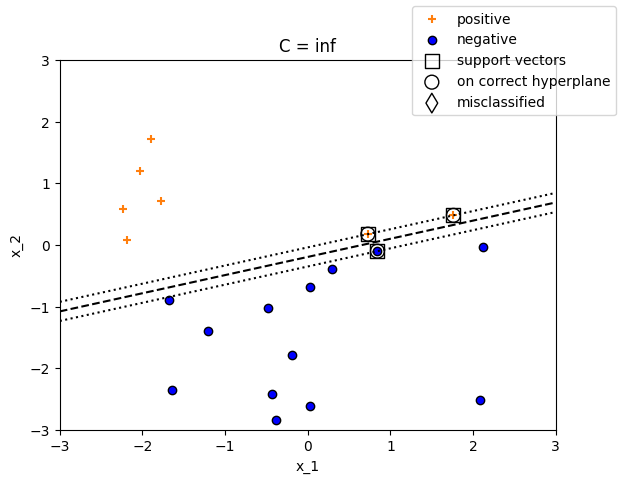

In [127]:
"""
To test the above try and plot it
"""
import matplotlib.pyplot as plt

def svm_plot(x, y, c, w, w0, lambda_):
  """
  Uses the gradient of the primal Lagrangian function for Support Vector
  Machines to estimate the weights, bias, and Lagrangian multipliers.
  :param x: data matrix (n x m)
  :param y: target vector {-1, 1} (length n)
  :param c: SVM 'C' parameter
  :param w: weight vector (length m)
  :param w0: bias (scalar)
  :param lambda_: Lagrangian multiplier vector (length n)
  :return:
  """
  fig, ax = plt.subplots()
  # plot positive samples
  index = y == 1
  ax.scatter(x[index, 0], x[index, 1], marker='+', c='tab:orange',
          edgecolors='black', label='positive')
  # plot negative samples
  index = y == -1
  ax.scatter(x[index, 0], x[index, 1], marker='o', c='blue',
         edgecolors='black', label='negative')
  # plot support vectors
  index = svm_support_vectors(lambda_, c)
  ax.scatter(x[index, 0], x[index, 1], marker='s', c='none', s=100,
            edgecolors='black', label='support vectors')
  # plot on correct hyperplane
  index = svm_on_correct_hyperplane(lambda_, c)
  ax.scatter(x[index, 0], x[index, 1], marker='o', c='none', s=100,
  edgecolors='black', label='on correct hyperplane')
  # plot misclassified
  index = svm_misclassified(svm_ksi(x, y, w, w0))
  ax.scatter(x[index, 0], x[index, 1], marker='d', c='none', s=100,
  edgecolors='black', label='misclassified')
  # plot boundary, negative- and positive-hyperplanes
  xx1, xx2 = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
  zz1 = w0 + w[0] * xx1 + w[1] * xx2
  ax.contour(xx1, xx2, zz1, levels=[-1, 0, 1],
  linestyles=['dotted', 'dashed', 'dotted'], colors='black')
  # add labels
  ax.set_xlabel('x_1')
  ax.set_ylabel('x_2')
  ax.set_title(f'C = {c}')
  fig.legend()
  plt.show()

svm_plot(x, y, c, w, w0, lambda_)

In [63]:
range(1,10)

range(1, 10)